# ACDADA — Notebook 05: Deception Simulation Environment

**Custom OpenAI Gym Environment for Cyber Deception RL Training**

This notebook implements:
1. A network simulation with hosts, services, and honeypots
2. An attacker model that probes/exploits the network
3. A Gymnasium-compatible environment for RL agent training
4. State/action/reward design for deception strategy learning
5. Environment validation and baseline testing

In [1]:
# ============================================================
# DATASET / REFERENCE LINKS
# ============================================================
#
# CybORG (Cyber Operations Research Gym) — reference architecture:
#   https://github.com/cage-challenge/CybORG
#
# This environment is a simplified custom Gym env inspired by
# CybORG but tailored for ACDADA's deception strategy learning.
#
# No external dataset needed — this notebook generates the
# simulation environment used by Notebook 06 (RL Agent).
# ============================================================

## 1. Imports & Configuration

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from enum import IntEnum
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Any
import gymnasium as gym
from gymnasium import spaces
import warnings
import json
import copy

warnings.filterwarnings('ignore')
np.random.seed(42)

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Gymnasium version: {gym.__version__}')

Gymnasium version: 1.2.3


---
## 2. Network Topology & Entities

In [3]:
class ServiceType(IntEnum):
    """Network service types available on hosts."""
    HTTP = 0
    SSH = 1
    FTP = 2
    DNS = 3
    DATABASE = 4
    SMTP = 5


class AttackPhase(IntEnum):
    """Attacker kill-chain phases."""
    RECONNAISSANCE = 0
    SCANNING = 1
    EXPLOITATION = 2
    LATERAL_MOVEMENT = 3
    EXFILTRATION = 4


class HostStatus(IntEnum):
    """Host compromise status."""
    SECURE = 0
    PROBED = 1
    COMPROMISED = 2


@dataclass
class Host:
    """Represents a network host (real or honeypot)."""
    host_id: int
    name: str
    is_honeypot: bool = False
    is_critical: bool = False
    services: List[int] = field(default_factory=list)
    vulnerability_score: float = 0.5  # 0-1, how easy to exploit
    status: int = HostStatus.SECURE
    value: float = 1.0  # asset value to defender


@dataclass
class NetworkState:
    """Full network state at a given timestep."""
    hosts: Dict[int, Host] = field(default_factory=dict)
    attacker_position: int = -1  # -1 = outside network
    attacker_phase: int = AttackPhase.RECONNAISSANCE
    attacker_detected: bool = False
    active_honeypots: List[int] = field(default_factory=list)
    alerts: List[dict] = field(default_factory=list)
    timestep: int = 0

In [4]:
def create_default_network(n_real_hosts: int = 8, n_honeypot_slots: int = 4) -> Dict[int, Host]:
    """
    Create a default network topology.
    
    Layout:
    - DMZ zone: 2 public-facing servers (HTTP, DNS)
    - Internal zone: workstations + DB servers
    - Honeypot slots: can be activated by defender
    """
    hosts = {}
    host_id = 0
    
    # DMZ servers
    hosts[host_id] = Host(
        host_id=host_id, name='web-server-01',
        services=[ServiceType.HTTP, ServiceType.SSH],
        vulnerability_score=0.6, is_critical=False, value=2.0
    )
    host_id += 1
    
    hosts[host_id] = Host(
        host_id=host_id, name='dns-server-01',
        services=[ServiceType.DNS, ServiceType.SSH],
        vulnerability_score=0.4, is_critical=False, value=1.5
    )
    host_id += 1
    
    # Internal servers
    hosts[host_id] = Host(
        host_id=host_id, name='db-server-01',
        services=[ServiceType.DATABASE, ServiceType.SSH],
        vulnerability_score=0.3, is_critical=True, value=5.0
    )
    host_id += 1
    
    hosts[host_id] = Host(
        host_id=host_id, name='mail-server-01',
        services=[ServiceType.SMTP, ServiceType.HTTP],
        vulnerability_score=0.5, is_critical=False, value=2.0
    )
    host_id += 1
    
    # Workstations
    for i in range(n_real_hosts - 4):
        hosts[host_id] = Host(
            host_id=host_id, name=f'workstation-{i+1:02d}',
            services=[ServiceType.HTTP, ServiceType.SSH, ServiceType.FTP],
            vulnerability_score=np.random.uniform(0.3, 0.7),
            value=1.0
        )
        host_id += 1
    
    # Honeypot slots (inactive by default)
    for i in range(n_honeypot_slots):
        # Each honeypot mimics a different service profile
        service_profiles = [
            [ServiceType.HTTP, ServiceType.SSH],
            [ServiceType.DATABASE, ServiceType.SSH],
            [ServiceType.FTP, ServiceType.HTTP],
            [ServiceType.SMTP, ServiceType.DNS],
        ]
        hosts[host_id] = Host(
            host_id=host_id, name=f'honeypot-{i+1:02d}',
            is_honeypot=True,
            services=service_profiles[i % len(service_profiles)],
            vulnerability_score=0.8,  # Deliberately attractive
            value=0.0  # No real value
        )
        host_id += 1
    
    return hosts


# Test
test_hosts = create_default_network()
for hid, host in test_hosts.items():
    hp_tag = ' [HONEYPOT]' if host.is_honeypot else ''
    crit_tag = ' [CRITICAL]' if host.is_critical else ''
    svcs = [ServiceType(s).name for s in host.services]
    print(f'  Host {hid}: {host.name:20s} services={svcs} vuln={host.vulnerability_score:.2f}{hp_tag}{crit_tag}')

  Host 0: web-server-01        services=['HTTP', 'SSH'] vuln=0.60
  Host 1: dns-server-01        services=['DNS', 'SSH'] vuln=0.40
  Host 2: db-server-01         services=['DATABASE', 'SSH'] vuln=0.30 [CRITICAL]
  Host 3: mail-server-01       services=['SMTP', 'HTTP'] vuln=0.50
  Host 4: workstation-01       services=['HTTP', 'SSH', 'FTP'] vuln=0.45
  Host 5: workstation-02       services=['HTTP', 'SSH', 'FTP'] vuln=0.68
  Host 6: workstation-03       services=['HTTP', 'SSH', 'FTP'] vuln=0.59
  Host 7: workstation-04       services=['HTTP', 'SSH', 'FTP'] vuln=0.54
  Host 8: honeypot-01          services=['HTTP', 'SSH'] vuln=0.80 [HONEYPOT]
  Host 9: honeypot-02          services=['DATABASE', 'SSH'] vuln=0.80 [HONEYPOT]
  Host 10: honeypot-03          services=['FTP', 'HTTP'] vuln=0.80 [HONEYPOT]
  Host 11: honeypot-04          services=['SMTP', 'DNS'] vuln=0.80 [HONEYPOT]


---
## 3. Attacker Model

A stochastic attacker that follows the cyber kill chain.
The attacker selects targets based on visibility and vulnerability.

In [5]:
class SimulatedAttacker:
    """
    Simulated attacker following a simplified kill chain.
    
    Behavior:
    - Reconnaissance: discovers hosts
    - Scanning: identifies services/vulnerabilities
    - Exploitation: attempts to compromise hosts
    - Lateral movement: moves to adjacent hosts
    - Exfiltration: extracts data from critical hosts
    
    The attacker is attracted to high-vulnerability hosts.
    Honeypots with high vuln scores should attract the attacker.
    """
    
    def __init__(self, skill_level: float = 0.5, persistence: float = 0.7):
        self.skill_level = np.clip(skill_level, 0.1, 1.0)
        self.persistence = persistence
        self.phase = AttackPhase.RECONNAISSANCE
        self.position = -1  # outside
        self.discovered_hosts = set()
        self.compromised_hosts = set()
        self.target_host = None
        self.stealth = 0.5  # detection avoidance
        self.time_in_network = 0
        self.exfiltrated_data = 0.0
    
    def reset(self):
        self.phase = AttackPhase.RECONNAISSANCE
        self.position = -1
        self.discovered_hosts = set()
        self.compromised_hosts = set()
        self.target_host = None
        self.time_in_network = 0
        self.exfiltrated_data = 0.0
    
    def step(self, hosts: Dict[int, Host], active_honeypots: List[int]) -> dict:
        """
        Attacker takes one action based on current phase.
        Returns action details for the environment.
        """
        action_log = {
            'phase': self.phase,
            'target': None,
            'success': False,
            'noise_level': 0.0,  # how detectable this action is
        }
        
        if self.phase == AttackPhase.RECONNAISSANCE:
            action_log = self._do_recon(hosts, active_honeypots)
        elif self.phase == AttackPhase.SCANNING:
            action_log = self._do_scan(hosts)
        elif self.phase == AttackPhase.EXPLOITATION:
            action_log = self._do_exploit(hosts)
        elif self.phase == AttackPhase.LATERAL_MOVEMENT:
            action_log = self._do_lateral(hosts)
        elif self.phase == AttackPhase.EXFILTRATION:
            action_log = self._do_exfiltrate(hosts)
        
        self.time_in_network += 1
        return action_log
    
    def _do_recon(self, hosts, active_honeypots):
        """Discover hosts — includes active honeypots (they look real)."""
        visible_hosts = []
        for hid, host in hosts.items():
            if not host.is_honeypot or hid in active_honeypots:
                visible_hosts.append(hid)
        
        # Discover 2-4 hosts per step
        n_discover = min(np.random.randint(2, 5), len(visible_hosts))
        newly_discovered = set(np.random.choice(
            visible_hosts, size=n_discover, replace=False
        ))
        self.discovered_hosts.update(newly_discovered)
        
        # Move to scanning when enough hosts discovered
        if len(self.discovered_hosts) >= 3:
            self.phase = AttackPhase.SCANNING
        
        return {
            'phase': AttackPhase.RECONNAISSANCE,
            'target': list(newly_discovered),
            'success': True,
            'noise_level': 0.2,
        }
    
    def _do_scan(self, hosts):
        """Scan discovered hosts for vulnerabilities."""
        if not self.discovered_hosts:
            self.phase = AttackPhase.RECONNAISSANCE
            return {'phase': AttackPhase.SCANNING, 'target': None, 'success': False, 'noise_level': 0.1}
        
        # Pick most vulnerable target
        candidates = [
            (hid, hosts[hid].vulnerability_score)
            for hid in self.discovered_hosts
            if hid not in self.compromised_hosts and hid in hosts
        ]
        
        if not candidates:
            self.phase = AttackPhase.RECONNAISSANCE
            return {'phase': AttackPhase.SCANNING, 'target': None, 'success': False, 'noise_level': 0.1}
        
        # Weighted selection — prefer more vulnerable hosts
        hids, vulns = zip(*candidates)
        vulns = np.array(vulns)
        probs = vulns / vulns.sum()
        self.target_host = np.random.choice(hids, p=probs)
        self.phase = AttackPhase.EXPLOITATION
        
        return {
            'phase': AttackPhase.SCANNING,
            'target': self.target_host,
            'success': True,
            'noise_level': 0.4,
        }
    
    def _do_exploit(self, hosts):
        """Attempt to exploit target host."""
        if self.target_host is None or self.target_host not in hosts:
            self.phase = AttackPhase.SCANNING
            return {'phase': AttackPhase.EXPLOITATION, 'target': None, 'success': False, 'noise_level': 0.3}
        
        target = hosts[self.target_host]
        # Exploit probability = skill * vulnerability
        exploit_prob = self.skill_level * target.vulnerability_score
        success = np.random.random() < exploit_prob
        
        if success:
            self.compromised_hosts.add(self.target_host)
            self.position = self.target_host
            target.status = HostStatus.COMPROMISED
            
            # Decide next phase
            if target.is_critical:
                self.phase = AttackPhase.EXFILTRATION
            else:
                self.phase = AttackPhase.LATERAL_MOVEMENT
        else:
            target.status = max(target.status, HostStatus.PROBED)
            # Retry or re-scan
            if np.random.random() < self.persistence:
                pass  # retry same target
            else:
                self.phase = AttackPhase.SCANNING
        
        return {
            'phase': AttackPhase.EXPLOITATION,
            'target': self.target_host,
            'success': success,
            'noise_level': 0.7,
        }
    
    def _do_lateral(self, hosts):
        """Move laterally to find critical assets."""
        # Find new targets from compromised position
        new_targets = [
            hid for hid in self.discovered_hosts
            if hid not in self.compromised_hosts and hid in hosts
        ]
        
        if not new_targets:
            self.phase = AttackPhase.RECONNAISSANCE
            return {'phase': AttackPhase.LATERAL_MOVEMENT, 'target': None, 'success': False, 'noise_level': 0.5}
        
        # Prefer critical hosts
        critical = [h for h in new_targets if hosts[h].is_critical]
        if critical:
            self.target_host = np.random.choice(critical)
        else:
            # Prefer high vulnerability
            vulns = np.array([hosts[h].vulnerability_score for h in new_targets])
            probs = vulns / vulns.sum()
            self.target_host = np.random.choice(new_targets, p=probs)
        
        self.phase = AttackPhase.EXPLOITATION
        return {
            'phase': AttackPhase.LATERAL_MOVEMENT,
            'target': self.target_host,
            'success': True,
            'noise_level': 0.5,
        }
    
    def _do_exfiltrate(self, hosts):
        """Extract data from compromised critical host."""
        critical_compromised = [
            hid for hid in self.compromised_hosts
            if hid in hosts and hosts[hid].is_critical
        ]
        
        if not critical_compromised:
            self.phase = AttackPhase.LATERAL_MOVEMENT
            return {'phase': AttackPhase.EXFILTRATION, 'target': None, 'success': False, 'noise_level': 0.3}
        
        target_id = critical_compromised[0]
        data_amount = hosts[target_id].value * self.skill_level
        self.exfiltrated_data += data_amount
        
        return {
            'phase': AttackPhase.EXFILTRATION,
            'target': target_id,
            'success': True,
            'noise_level': 0.8,
            'data_exfiltrated': data_amount,
        }

print('SimulatedAttacker defined.')

SimulatedAttacker defined.


---
## 4. Gymnasium Environment

In [6]:
class CyberDeceptionEnv(gym.Env):
    """
    Gymnasium environment for training a cyber deception RL agent.
    
    The defender (agent) must decide which deception actions to take
    in response to an ongoing attack to maximize attacker engagement
    with honeypots while minimizing real asset compromise.
    
    STATE (observation):
    For each host: [status, is_honeypot_active, vulnerability, is_critical,
                    n_services, was_probed, was_compromised]
    Global: [attacker_detected, attacker_phase_onehot(5), timestep_normalized,
             n_compromised, n_honeypots_active, alert_level]
    
    ACTIONS (Discrete):
    0: Do nothing (observe)
    1: Activate honeypot 0
    2: Activate honeypot 1
    3: Activate honeypot 2
    4: Activate honeypot 3
    5: Deactivate all honeypots
    6: Redirect attacker to honeypot (if detected)
    7: Issue alert & increase monitoring
    8: Block detected attacker
    
    REWARDS:
    + Attacker interacts with honeypot (deception success)
    + Attacker detected early
    - Real host compromised
    - Critical asset exfiltrated
    - Unnecessary honeypot deployment (resource cost)
    """
    
    metadata = {'render_modes': ['human', 'ansi']}
    
    def __init__(self, n_real_hosts=8, n_honeypots=4, max_steps=100,
                 attacker_skill=0.5, render_mode=None):
        super().__init__()
        
        self.n_real_hosts = n_real_hosts
        self.n_honeypots = n_honeypots
        self.n_total_hosts = n_real_hosts + n_honeypots
        self.max_steps = max_steps
        self.attacker_skill = attacker_skill
        self.render_mode = render_mode
        
        # Per-host features (7) + global features (11)
        self.host_features = 7
        self.global_features = 11
        obs_size = self.n_total_hosts * self.host_features + self.global_features
        
        # Spaces
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(obs_size,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(9)  # 9 actions
        
        # State
        self.hosts = {}
        self.attacker = None
        self.active_honeypots = []
        self.current_step = 0
        self.monitoring_level = 0.0
        self.attacker_blocked = False
        
        # Metrics
        self.episode_rewards = []
        self.honeypot_interactions = 0
        self.real_compromises = 0
        self.detection_time = -1
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        self.hosts = create_default_network(self.n_real_hosts, self.n_honeypots)
        self.attacker = SimulatedAttacker(skill_level=self.attacker_skill)
        self.active_honeypots = []
        self.current_step = 0
        self.monitoring_level = 0.3  # baseline monitoring
        self.attacker_blocked = False
        self.honeypot_interactions = 0
        self.real_compromises = 0
        self.detection_time = -1
        
        return self._get_observation(), {}
    
    def _get_observation(self) -> np.ndarray:
        """Construct observation vector."""
        obs = []
        
        # Per-host features
        for hid in range(self.n_total_hosts):
            host = self.hosts[hid]
            obs.extend([
                host.status / 2.0,  # normalized status
                1.0 if (host.is_honeypot and hid in self.active_honeypots) else 0.0,
                host.vulnerability_score,
                1.0 if host.is_critical else 0.0,
                len(host.services) / 6.0,  # normalized
                1.0 if host.status >= HostStatus.PROBED else 0.0,
                1.0 if host.status >= HostStatus.COMPROMISED else 0.0,
            ])
        
        # Global features
        attacker_detected = self._is_attacker_detected()
        phase_onehot = [0.0] * 5
        if attacker_detected:
            phase_onehot[int(self.attacker.phase)] = 1.0
        
        n_compromised = sum(1 for h in self.hosts.values() if h.status == HostStatus.COMPROMISED)
        n_probed = sum(1 for h in self.hosts.values() if h.status >= HostStatus.PROBED)
        
        obs.extend([
            1.0 if attacker_detected else 0.0,
            *phase_onehot,
            self.current_step / self.max_steps,
            n_compromised / self.n_total_hosts,
            len(self.active_honeypots) / max(self.n_honeypots, 1),
            n_probed / self.n_total_hosts,
            self.monitoring_level,
        ])
        
        return np.array(obs, dtype=np.float32)
    
    def _is_attacker_detected(self) -> bool:
        """Determine if the attacker's activity has been detected."""
        if self.attacker_blocked:
            return True
        # Detection probability increases with monitoring and attacker noise
        base_detection = self.monitoring_level * 0.3
        # Honeypot interaction = guaranteed detection
        for hid in self.attacker.compromised_hosts:
            if hid in self.active_honeypots:
                return True
        # Noisy actions are more detectable
        noise_factor = {
            AttackPhase.RECONNAISSANCE: 0.1,
            AttackPhase.SCANNING: 0.3,
            AttackPhase.EXPLOITATION: 0.5,
            AttackPhase.LATERAL_MOVEMENT: 0.4,
            AttackPhase.EXFILTRATION: 0.6,
        }.get(self.attacker.phase, 0.1)
        
        detection_prob = base_detection + noise_factor * self.monitoring_level
        return np.random.random() < detection_prob
    
    def step(self, action: int):
        """
        Execute one timestep.
        1. Defender takes action
        2. Attacker takes action
        3. Compute reward
        4. Check termination
        """
        self.current_step += 1
        reward = 0.0
        info = {'action_name': '', 'attacker_action': {}}
        
        # ==================
        # 1. Defender Action
        # ==================
        honeypot_ids = [hid for hid, h in self.hosts.items() if h.is_honeypot]
        
        if action == 0:  # Do nothing
            info['action_name'] = 'observe'
        
        elif 1 <= action <= 4:  # Activate honeypot
            hp_idx = action - 1
            if hp_idx < len(honeypot_ids):
                hp_id = honeypot_ids[hp_idx]
                if hp_id not in self.active_honeypots:
                    self.active_honeypots.append(hp_id)
                    reward -= 0.05  # small cost for deployment
                    info['action_name'] = f'activate_honeypot_{hp_idx}'
                else:
                    reward -= 0.01  # already active
                    info['action_name'] = f'honeypot_{hp_idx}_already_active'
        
        elif action == 5:  # Deactivate all
            self.active_honeypots = []
            info['action_name'] = 'deactivate_all_honeypots'
        
        elif action == 6:  # Redirect to honeypot
            if self._is_attacker_detected() and self.active_honeypots:
                # Redirect attacker to a honeypot
                redirect_target = np.random.choice(self.active_honeypots)
                self.attacker.target_host = redirect_target
                self.attacker.phase = AttackPhase.EXPLOITATION
                reward += 0.3  # good deception move
                info['action_name'] = f'redirect_to_honeypot_{redirect_target}'
            else:
                reward -= 0.02
                info['action_name'] = 'redirect_failed_no_detection'
        
        elif action == 7:  # Increase monitoring
            self.monitoring_level = min(1.0, self.monitoring_level + 0.15)
            reward -= 0.03  # monitoring has a cost
            info['action_name'] = 'increase_monitoring'
        
        elif action == 8:  # Block attacker
            if self._is_attacker_detected():
                self.attacker_blocked = True
                reward += 1.0  # good: blocked a detected attacker
                info['action_name'] = 'block_attacker'
            else:
                reward -= 0.5  # penalty: blocking without detection
                info['action_name'] = 'block_failed_no_detection'
        
        # ==================
        # 2. Attacker Action
        # ==================
        attacker_action = {'phase': -1, 'target': None, 'success': False}
        if not self.attacker_blocked:
            attacker_action = self.attacker.step(self.hosts, self.active_honeypots)
            info['attacker_action'] = attacker_action
            
            # Check if attacker interacted with honeypot
            target = attacker_action.get('target')
            if target is not None:
                if isinstance(target, (list, np.ndarray)):
                    for t in target:
                        if t in self.active_honeypots:
                            self.honeypot_interactions += 1
                            reward += 0.5  # deception success
                elif target in self.active_honeypots:
                    self.honeypot_interactions += 1
                    reward += 0.5
                    if attacker_action.get('success'):
                        reward += 1.0  # attacker wasted time on honeypot
            
            # Penalty for real host compromise
            if attacker_action.get('success') and target is not None:
                if not isinstance(target, (list, np.ndarray)):
                    if target in self.hosts and not self.hosts[target].is_honeypot:
                        self.real_compromises += 1
                        host_value = self.hosts[target].value
                        reward -= host_value * 0.5
                        if self.hosts[target].is_critical:
                            reward -= 2.0  # critical asset compromised
            
            # Exfiltration penalty
            if attacker_action.get('data_exfiltrated', 0) > 0:
                reward -= attacker_action['data_exfiltrated'] * 2.0
        
        # Detection timing reward
        if self.detection_time == -1 and self._is_attacker_detected():
            self.detection_time = self.current_step
            early_bonus = max(0, 1.0 - self.current_step / self.max_steps)
            reward += early_bonus
        
        # ==================
        # 3. Termination
        # ==================
        terminated = False
        truncated = False
        
        # Terminate if attacker blocked
        if self.attacker_blocked:
            terminated = True
        
        # Terminate if critical asset exfiltrated
        if self.attacker.exfiltrated_data > 5.0:
            terminated = True
            reward -= 5.0
        
        # Truncate if max steps reached
        if self.current_step >= self.max_steps:
            truncated = True
            # Small penalty for not resolving
            if not self.attacker_blocked:
                reward -= 1.0
        
        obs = self._get_observation()
        
        # Episode summary in info
        info['honeypot_interactions'] = self.honeypot_interactions
        info['real_compromises'] = self.real_compromises
        info['detection_time'] = self.detection_time
        info['attacker_time_in_network'] = self.attacker.time_in_network
        info['exfiltrated_data'] = self.attacker.exfiltrated_data
        
        return obs, reward, terminated, truncated, info
    
    def render(self):
        if self.render_mode == 'ansi':
            return self._render_ansi()
        elif self.render_mode == 'human':
            print(self._render_ansi())
    
    def _render_ansi(self) -> str:
        lines = [f'\n=== Step {self.current_step}/{self.max_steps} ===']
        lines.append(f'Monitoring: {self.monitoring_level:.2f} | Active honeypots: {self.active_honeypots}')
        lines.append(f'Attacker phase: {AttackPhase(self.attacker.phase).name} | Position: {self.attacker.position}')
        lines.append(f'Blocked: {self.attacker_blocked} | Detection time: {self.detection_time}')
        lines.append(f'Honeypot interactions: {self.honeypot_interactions} | Real compromises: {self.real_compromises}')
        lines.append('Hosts:')
        for hid, host in self.hosts.items():
            status = HostStatus(host.status).name
            hp = ' [HP-ACTIVE]' if hid in self.active_honeypots else (' [HP]' if host.is_honeypot else '')
            lines.append(f'  {host.name:20s} status={status:12s} vuln={host.vulnerability_score:.2f}{hp}')
        return '\n'.join(lines)

print('CyberDeceptionEnv defined.')

CyberDeceptionEnv defined.


---
## 5. Environment Validation

In [7]:
# Basic validation
env = CyberDeceptionEnv(render_mode='human')
obs, info = env.reset()

print(f'Observation shape: {obs.shape}')
print(f'Observation space: {env.observation_space}')
print(f'Action space: {env.action_space}')
print(f'Obs range: [{obs.min():.3f}, {obs.max():.3f}]')

# Verify observation is within bounds
assert env.observation_space.contains(obs), 'Observation out of bounds!'
print('\n✓ Observation space valid')

Observation shape: (95,)
Observation space: Box(0.0, 1.0, (95,), float32)
Action space: Discrete(9)
Obs range: [0.000, 1.000]

✓ Observation space valid


In [8]:
# Run a short episode with random actions
env = CyberDeceptionEnv(max_steps=20, render_mode='human')
obs, _ = env.reset(seed=42)

total_reward = 0
for step in range(20):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    
    action_names = ['observe', 'hp0', 'hp1', 'hp2', 'hp3', 'deactivate', 'redirect', 'monitor', 'block']
    print(f'Step {step+1}: action={action_names[action]:12s} reward={reward:+.3f} '
          f'atk_phase={info["attacker_action"].get("phase", -1)}')
    
    if terminated or truncated:
        print(f'\nEpisode ended: terminated={terminated}, truncated={truncated}')
        break

print(f'\nTotal reward: {total_reward:.3f}')
print(f'Honeypot interactions: {info["honeypot_interactions"]}')
print(f'Real compromises: {info["real_compromises"]}')

Step 1: action=redirect     reward=-0.020 atk_phase=0
Step 2: action=monitor      reward=-0.030 atk_phase=0
Step 3: action=redirect     reward=-0.170 atk_phase=1
Step 4: action=hp0          reward=-0.050 atk_phase=2
Step 5: action=hp0          reward=-1.010 atk_phase=1
Step 6: action=monitor      reward=-0.030 atk_phase=2
Step 7: action=hp0          reward=-1.010 atk_phase=2
Step 8: action=redirect     reward=+0.800 atk_phase=2
Step 9: action=observe      reward=+0.500 atk_phase=2
Step 10: action=hp2          reward=+0.450 atk_phase=2
Step 11: action=monitor      reward=-0.530 atk_phase=1
Step 12: action=hp0          reward=-0.510 atk_phase=2
Step 13: action=redirect     reward=+0.800 atk_phase=2
Step 14: action=observe      reward=-1.000 atk_phase=1
Step 15: action=hp3          reward=-0.050 atk_phase=2
Step 16: action=hp3          reward=-1.010 atk_phase=2
Step 17: action=hp0          reward=-4.510 atk_phase=3
Step 18: action=hp0          reward=-0.010 atk_phase=2
Step 19: action=hp3

---
## 6. Baseline Agents for Comparison

In [9]:
class RandomAgent:
    """Baseline: random actions."""
    def __init__(self, action_space):
        self.action_space = action_space
    def predict(self, obs):
        return self.action_space.sample(), None


class AlwaysMonitorAgent:
    """Baseline: always increase monitoring, then block."""
    def __init__(self):
        self.step_count = 0
    def predict(self, obs):
        self.step_count += 1
        if self.step_count < 5:
            return 7, None  # monitor
        elif self.step_count < 10:
            return 1, None  # activate honeypot 0
        else:
            return 8, None  # block


class HeuristicDefender:
    """Baseline: rule-based defender using observation heuristics."""
    def predict(self, obs):
        # Parse key features from observation
        # Global features are at the end
        attacker_detected = obs[-11] > 0.5
        n_compromised = obs[-5]
        n_honeypots_active = obs[-4]
        n_probed = obs[-3]
        
        if attacker_detected and n_compromised > 0.2:
            return 8, None  # block
        elif attacker_detected and n_honeypots_active > 0:
            return 6, None  # redirect
        elif n_probed > 0.1 and n_honeypots_active < 0.5:
            return np.random.choice([1, 2, 3, 4]), None  # activate honeypot
        elif n_probed > 0:
            return 7, None  # monitor
        else:
            return 0, None  # observe


def evaluate_agent(agent, env, n_episodes=100):
    """Run agent for n episodes and collect metrics."""
    rewards = []
    hp_interactions = []
    real_compromises = []
    detection_times = []
    episode_lengths = []
    
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=ep)
        total_reward = 0
        done = False
        steps = 0
        
        if hasattr(agent, 'step_count'):
            agent.step_count = 0
        
        while not done:
            action, _ = agent.predict(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated
            steps += 1
        
        rewards.append(total_reward)
        hp_interactions.append(info['honeypot_interactions'])
        real_compromises.append(info['real_compromises'])
        detection_times.append(info['detection_time'])
        episode_lengths.append(steps)
    
    return {
        'rewards': np.array(rewards),
        'hp_interactions': np.array(hp_interactions),
        'real_compromises': np.array(real_compromises),
        'detection_times': np.array(detection_times),
        'episode_lengths': np.array(episode_lengths),
    }

print('Baseline agents defined.')

Baseline agents defined.


In [10]:
# Evaluate baselines
env = CyberDeceptionEnv(max_steps=100)
n_eval = 200

baselines = {
    'Random': RandomAgent(env.action_space),
    'AlwaysMonitor': AlwaysMonitorAgent(),
    'Heuristic': HeuristicDefender(),
}

baseline_results = {}
for name, agent in baselines.items():
    print(f'\nEvaluating {name}...')
    results = evaluate_agent(agent, env, n_episodes=n_eval)
    baseline_results[name] = results
    
    print(f'  Avg reward:       {results["rewards"].mean():.3f} ± {results["rewards"].std():.3f}')
    print(f'  Avg HP interact:  {results["hp_interactions"].mean():.2f}')
    print(f'  Avg real comprom: {results["real_compromises"].mean():.2f}')
    print(f'  Avg episode len:  {results["episode_lengths"].mean():.1f}')


Evaluating Random...
  Avg reward:       -11.330 ± 17.184
  Avg HP interact:  1.75
  Avg real comprom: 6.38
  Avg episode len:  16.8

Evaluating AlwaysMonitor...
  Avg reward:       -7.840 ± 12.284
  Avg HP interact:  0.00
  Avg real comprom: 4.45
  Avg episode len:  10.3

Evaluating Heuristic...
  Avg reward:       -33.138 ± 20.564
  Avg HP interact:  0.00
  Avg real comprom: 13.04
  Avg episode len:  29.5


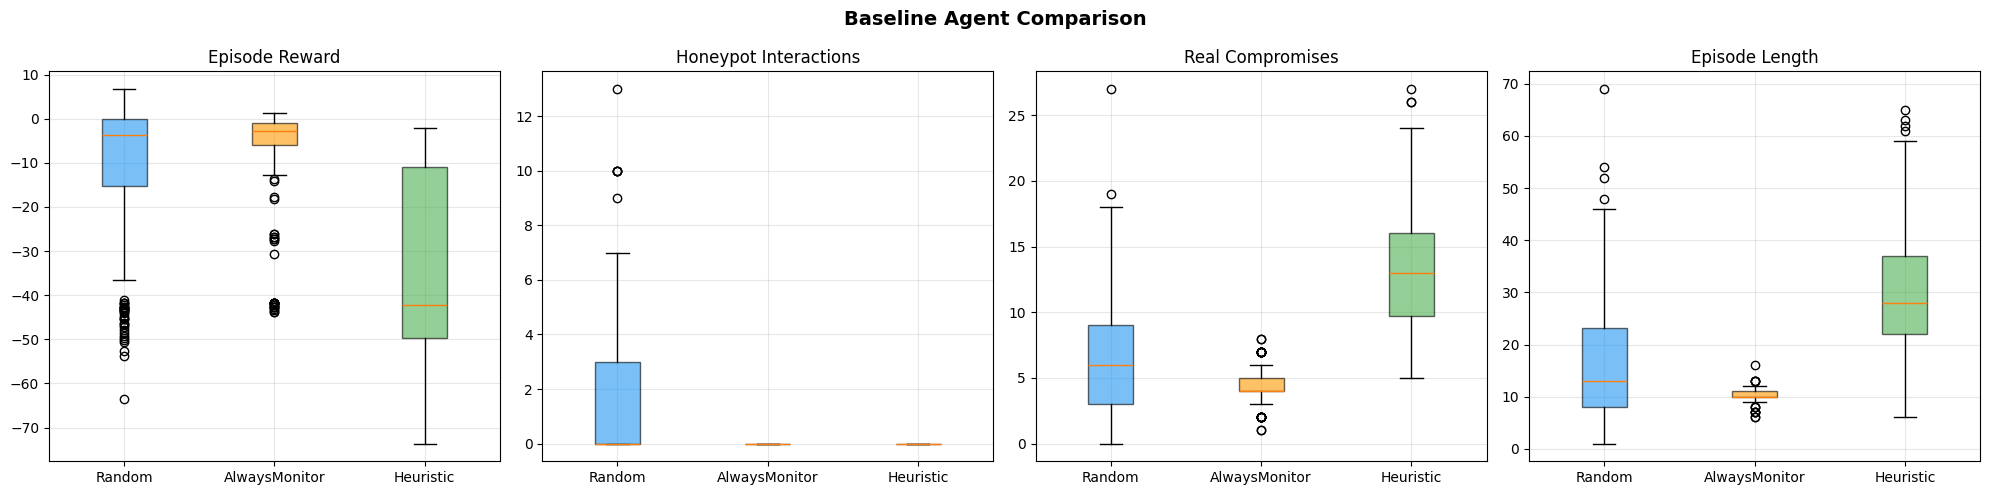

In [11]:
# Visualize baseline results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Baseline Agent Comparison', fontsize=14, fontweight='bold')

metrics = ['rewards', 'hp_interactions', 'real_compromises', 'episode_lengths']
titles = ['Episode Reward', 'Honeypot Interactions', 'Real Compromises', 'Episode Length']
colors = ['#2196F3', '#FF9800', '#4CAF50']

for ax, metric, title in zip(axes, metrics, titles):
    data = [baseline_results[name][metric] for name in baselines]
    bp = ax.boxplot(data, labels=list(baselines.keys()), patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 7. Save Environment for RL Training

In [13]:
# Save environment config
env_config = {
    'n_real_hosts': 8,
    'n_honeypots': 4,
    'max_steps': 100,
    'attacker_skill': 0.5,
    'obs_size': int(env.observation_space.shape[0]),
    'n_actions': int(env.action_space.n),
    'action_names': [
        'observe', 'activate_hp_0', 'activate_hp_1',
        'activate_hp_2', 'activate_hp_3', 'deactivate_all',
        'redirect_to_hp', 'increase_monitoring', 'block_attacker'
    ],
}

env_dir = MODELS_DIR / 'deception_env'
env_dir.mkdir(parents=True, exist_ok=True)

with open(env_dir / 'env_config.json', 'w') as f:
    json.dump(env_config, f, indent=2)

# Save baseline results
baseline_summary = {}
for name, results in baseline_results.items():
    baseline_summary[name] = {
        'mean_reward': float(results['rewards'].mean()),
        'std_reward': float(results['rewards'].std()),
        'mean_hp_interactions': float(results['hp_interactions'].mean()),
        'mean_real_compromises': float(results['real_compromises'].mean()),
    }

with open(env_dir / 'baseline_results.json', 'w') as f:
    json.dump(baseline_summary, f, indent=2)

print(f'Environment config saved to {env_dir}')
print(f'Baseline results saved.')
print(f'\n✓ Notebook 05 complete. Ready for Notebook 06 (RL Agent).')

Environment config saved to ..\models\deception_env
Baseline results saved.

✓ Notebook 05 complete. Ready for Notebook 06 (RL Agent).


In [14]:
# =============================================================================
# PRODUCTION VALIDATION - DECEPTION ENVIRONMENT
# =============================================================================
print("=" * 70)
print("PRODUCTION VALIDATION - CYBER DECEPTION ENVIRONMENT")
print("=" * 70)

# Validation criteria
validation_results = []

# 1. Environment stability - run many episodes without crashes
print("\n[1] STABILITY TEST - 500 episodes...")
stability_env = CyberDeceptionEnv(max_steps=100)
n_stability_tests = 500
stability_passed = True
try:
    for ep in range(n_stability_tests):
        obs, _ = stability_env.reset(seed=ep)
        done = False
        while not done:
            action = stability_env.action_space.sample()
            obs, _, terminated, truncated, _ = stability_env.step(action)
            done = terminated or truncated
            assert stability_env.observation_space.contains(obs), f"Invalid obs at ep {ep}"
    print(f"    ✓ PASSED - {n_stability_tests} episodes without crashes")
    validation_results.append(("Stability", True, f"{n_stability_tests} episodes"))
except Exception as e:
    print(f"    ✗ FAILED - {e}")
    stability_passed = False
    validation_results.append(("Stability", False, str(e)))

# 2. Observation space consistency
print("\n[2] OBSERVATION SPACE VALIDATION...")
test_env = CyberDeceptionEnv()
obs_samples = []
for _ in range(100):
    obs, _ = test_env.reset()
    obs_samples.append(obs)
    for _ in range(10):
        obs, _, _, _, _ = test_env.step(test_env.action_space.sample())
        obs_samples.append(obs)

obs_array = np.array(obs_samples)
obs_valid = (obs_array.min() >= 0.0) and (obs_array.max() <= 1.0)
print(f"    Observation range: [{obs_array.min():.4f}, {obs_array.max():.4f}]")
print(f"    Shape consistency: {obs_array.shape[1]} features")
if obs_valid:
    print("    ✓ PASSED - All observations within [0, 1] bounds")
    validation_results.append(("Observation Space", True, "Valid bounds"))
else:
    print("    ✗ FAILED - Observations out of bounds")
    validation_results.append(("Observation Space", False, "Out of bounds"))

# 3. Reward function sanity
print("\n[3] REWARD FUNCTION VALIDATION...")
reward_samples = []
for ep in range(100):
    _, _ = test_env.reset(seed=ep)
    ep_reward = 0
    done = False
    while not done:
        _, r, term, trunc, _ = test_env.step(test_env.action_space.sample())
        ep_reward += r
        done = term or trunc
    reward_samples.append(ep_reward)

rewards_arr = np.array(reward_samples)
print(f"    Reward range: [{rewards_arr.min():.2f}, {rewards_arr.max():.2f}]")
print(f"    Mean reward: {rewards_arr.mean():.2f} ± {rewards_arr.std():.2f}")

# Rewards should have reasonable variance (not all same)
reward_variance_ok = rewards_arr.std() > 0.1
if reward_variance_ok:
    print("    ✓ PASSED - Reward function has meaningful variance")
    validation_results.append(("Reward Function", True, f"σ={rewards_arr.std():.2f}"))
else:
    print("    ✗ FAILED - Reward function lacks variance")
    validation_results.append(("Reward Function", False, "No variance"))

# 4. Action space coverage
print("\n[4] ACTION SPACE COVERAGE...")
action_counts = {i: 0 for i in range(test_env.action_space.n)}
total_actions = 0
for ep in range(50):
    _, _ = test_env.reset(seed=ep)
    done = False
    while not done:
        action = test_env.action_space.sample()
        action_counts[action] += 1
        total_actions += 1
        _, _, term, trunc, _ = test_env.step(action)
        done = term or trunc

print(f"    Total actions sampled: {total_actions}")
action_coverage = sum(1 for c in action_counts.values() if c > 0) / len(action_counts)
print(f"    Action coverage: {action_coverage*100:.1f}%")
if action_coverage == 1.0:
    print("    ✓ PASSED - All actions reachable")
    validation_results.append(("Action Coverage", True, "100%"))
else:
    print("    ✗ FAILED - Some actions unreachable")
    validation_results.append(("Action Coverage", False, f"{action_coverage*100:.1f}%"))

# 5. Baseline performance benchmark
print("\n[5] BASELINE PERFORMANCE BENCHMARK...")
best_baseline = min(baseline_results.items(), key=lambda x: -x[1]['rewards'].mean())
best_name, best_res = best_baseline
print(f"    Best baseline: {best_name}")
print(f"    Mean reward: {best_res['rewards'].mean():.3f}")
print(f"    This establishes the performance floor for RL agents")
validation_results.append(("Baseline Benchmark", True, f"{best_name}: {best_res['rewards'].mean():.2f}"))

# Summary
print("\n" + "=" * 70)
print("PRODUCTION VALIDATION SUMMARY")
print("=" * 70)
all_passed = all(r[1] for r in validation_results)
for name, passed, detail in validation_results:
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {name:25s} {status:8s} ({detail})")

print("-" * 70)
if all_passed:
    print("✓ ENVIRONMENT MEETS PRODUCTION REQUIREMENTS")
else:
    print("✗ ENVIRONMENT NEEDS FIXES BEFORE PRODUCTION")
print("=" * 70)

PRODUCTION VALIDATION - CYBER DECEPTION ENVIRONMENT

[1] STABILITY TEST - 500 episodes...
    ✓ PASSED - 500 episodes without crashes

[2] OBSERVATION SPACE VALIDATION...
    Observation range: [0.0000, 1.0000]
    Shape consistency: 95 features
    ✓ PASSED - All observations within [0, 1] bounds

[3] REWARD FUNCTION VALIDATION...
    Reward range: [-63.02, 5.73]
    Mean reward: -10.72 ± 18.03
    ✓ PASSED - Reward function has meaningful variance

[4] ACTION SPACE COVERAGE...
    Total actions sampled: 773
    Action coverage: 100.0%
    ✓ PASSED - All actions reachable

[5] BASELINE PERFORMANCE BENCHMARK...
    Best baseline: AlwaysMonitor
    Mean reward: -7.840
    This establishes the performance floor for RL agents

PRODUCTION VALIDATION SUMMARY
  Stability                 ✓ PASS   (500 episodes)
  Observation Space         ✓ PASS   (Valid bounds)
  Reward Function           ✓ PASS   (σ=18.03)
  Action Coverage           ✓ PASS   (100%)
  Baseline Benchmark        ✓ PASS   (Alw